# 🧠 Brain Tumor MRI — Vision Transformer (ViT)

**Reference:** [marvelefe/vit-brain-tumor](https://github.com/marvelefe/vit-brain-tumor/tree/main)

**Dataset:** [Brain Tumor MRI Dataset — Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

**Model:** ViT-B/16 (PyTorch `torchvision.models`, pretrained on ImageNet)  
**Framework:** PyTorch
---

This notebook combines all scripts from the original repository into one runnable Colab file:

| Original Script | This Notebook Section |
|---|---|
| `cleanup.py` | Section 3 — Dataset Cleanup |
| `transformer.py` | Section 4 — ViT Model |
| `train.py` | Section 5 — Training |
| `test.py` | Section 6 — Testing / Inference |

### Dataset
| Class | Train | Test |
|---|---|---|
| glioma | 1321 | 300 |
| meningioma | 1339 | 306 |
| notumor | 1595 | 405 |
| pituitary | 1457 | 300 |
| **Total** | **5712** | **1311** |

## Section 1 — Install & Import
> Only `kaggle` needs installing. Everything else (`torch`, `torchvision`, `PIL`, `sklearn`) is pre-installed on Colab.

In [1]:
# Only kaggle needs to be installed — everything else is already on Colab
!pip install -q kaggle

import os
import shutil
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch   : {torch.__version__}')
print(f'Device    : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

PyTorch   : 2.10.0+cu128
Device    : cuda
GPU       : Tesla T4
VRAM      : 15.6 GB


## Section 2 — Download Dataset from Kaggle

In [2]:


!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/data --unzip -q
print('\n✅ Dataset downloaded!')

TRAIN_DIR = Path('/content/data/Training')
TEST_DIR  = Path('/content/data/Testing')

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)

✅ Dataset downloaded!
Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


## Section 3 — Dataset Cleanup (`cleanup.py`)

Equivalent to the original `cleanup.py` script:  
- Resize all images to `224×224`  
- Remove any corrupt or unreadable files  
- Print class distribution after cleanup

In [3]:
# ── cleanup.py ────────────────────────────────────────────────────────────
IMG_SIZE = (224, 224)

def cleanup_dataset(base_dir: Path, img_size=IMG_SIZE):
    """
    Resize images to target size and remove corrupt files.
    Equivalent to cleanup.py in marvelefe/vit-brain-tumor.
    """
    total_ok  = 0
    total_bad = 0

    class_dirs = sorted([d for d in base_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        ok = 0
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
                continue
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size, Image.LANCZOS)
                img.save(img_path)        # overwrite with resized version
                ok += 1
            except Exception:
                img_path.unlink(missing_ok=True)   # remove corrupt file
                total_bad += 1
        print(f'  {cls_dir.name:<15}: {ok} images')
        total_ok += ok

    return total_ok, total_bad


print('Cleaning Training set...')
ok_tr, bad_tr = cleanup_dataset(TRAIN_DIR)
print(f'  → {ok_tr} OK | {bad_tr} removed\n')

print('Cleaning Testing set...')
ok_te, bad_te = cleanup_dataset(TEST_DIR)
print(f'  → {ok_te} OK | {bad_te} removed')

Cleaning Training set...
  glioma         : 1400 images
  meningioma     : 1400 images
  notumor        : 1400 images
  pituitary      : 1400 images
  → 5600 OK | 0 removed

Cleaning Testing set...
  glioma         : 400 images
  meningioma     : 400 images
  notumor        : 400 images
  pituitary      : 400 images
  → 1600 OK | 0 removed


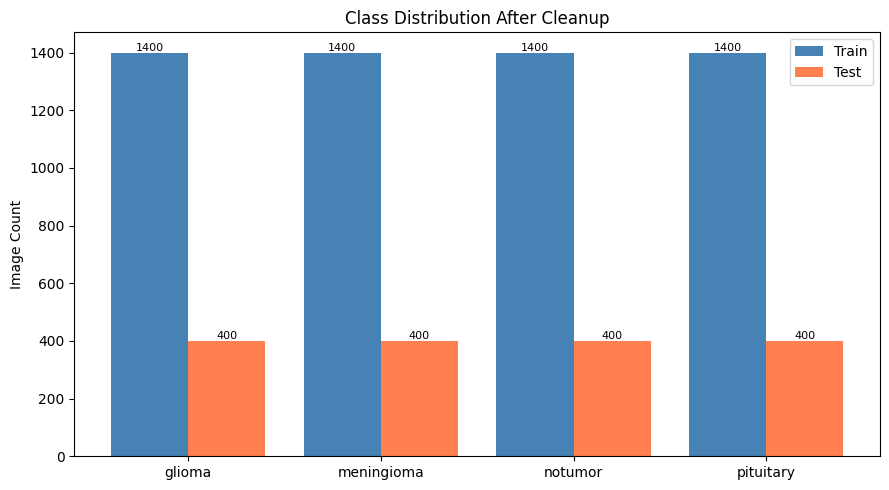

In [4]:
# Visualise class distribution after cleanup
train_counts = [len(list((TRAIN_DIR / c).glob('*.jpg')) +
                    list((TRAIN_DIR / c).glob('*.jpeg')) +
                    list((TRAIN_DIR / c).glob('*.png')))
                for c in CLASS_NAMES]
test_counts  = [len(list((TEST_DIR  / c).glob('*.jpg')) +
                    list((TEST_DIR  / c).glob('*.jpeg')) +
                    list((TEST_DIR  / c).glob('*.png')))
                for c in CLASS_NAMES]

x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, train_counts, 0.4, label='Train', color='steelblue')
ax.bar(x + 0.2, test_counts,  0.4, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution After Cleanup')
ax.legend()
for i, (tc, vc) in enumerate(zip(train_counts, test_counts)):
    ax.text(i - 0.2, tc + 5, str(tc), ha='center', fontsize=8)
    ax.text(i + 0.2, vc + 5, str(vc), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Section 4 — Transforms & Data Loading

Equivalent to the transform pipeline defined across the original scripts.

**Training transforms:**
- Resize → `224×224`  
- `RandomHorizontalFlip`  
- `RandomRotation(±15°)`  
- `ColorJitter(brightness, contrast)`  
- `ToTensor` + ImageNet `Normalize`

**Test transforms:** Resize → `ToTensor` → `Normalize` (no augmentation)

In [5]:
# ── Transforms (from train.py / test.py) ─────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Datasets ──────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
test_dataset  = datasets.ImageFolder(str(TEST_DIR),  transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train samples   : {len(train_dataset)}')
print(f'Test  samples   : {len(test_dataset)}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Train batches   : {len(train_loader)}')
print(f'Test  batches   : {len(test_loader)}')
print(f'Class mapping   : {train_dataset.class_to_idx}')

# Sanity-check a batch
imgs, labels = next(iter(train_loader))
print(f'\nSample batch → images: {imgs.shape}  labels: {labels.shape}')

Train samples   : 5600
Test  samples   : 1600
Batch size      : 32
Train batches   : 175
Test  batches   : 50
Class mapping   : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Sample batch → images: torch.Size([32, 3, 224, 224])  labels: torch.Size([32])


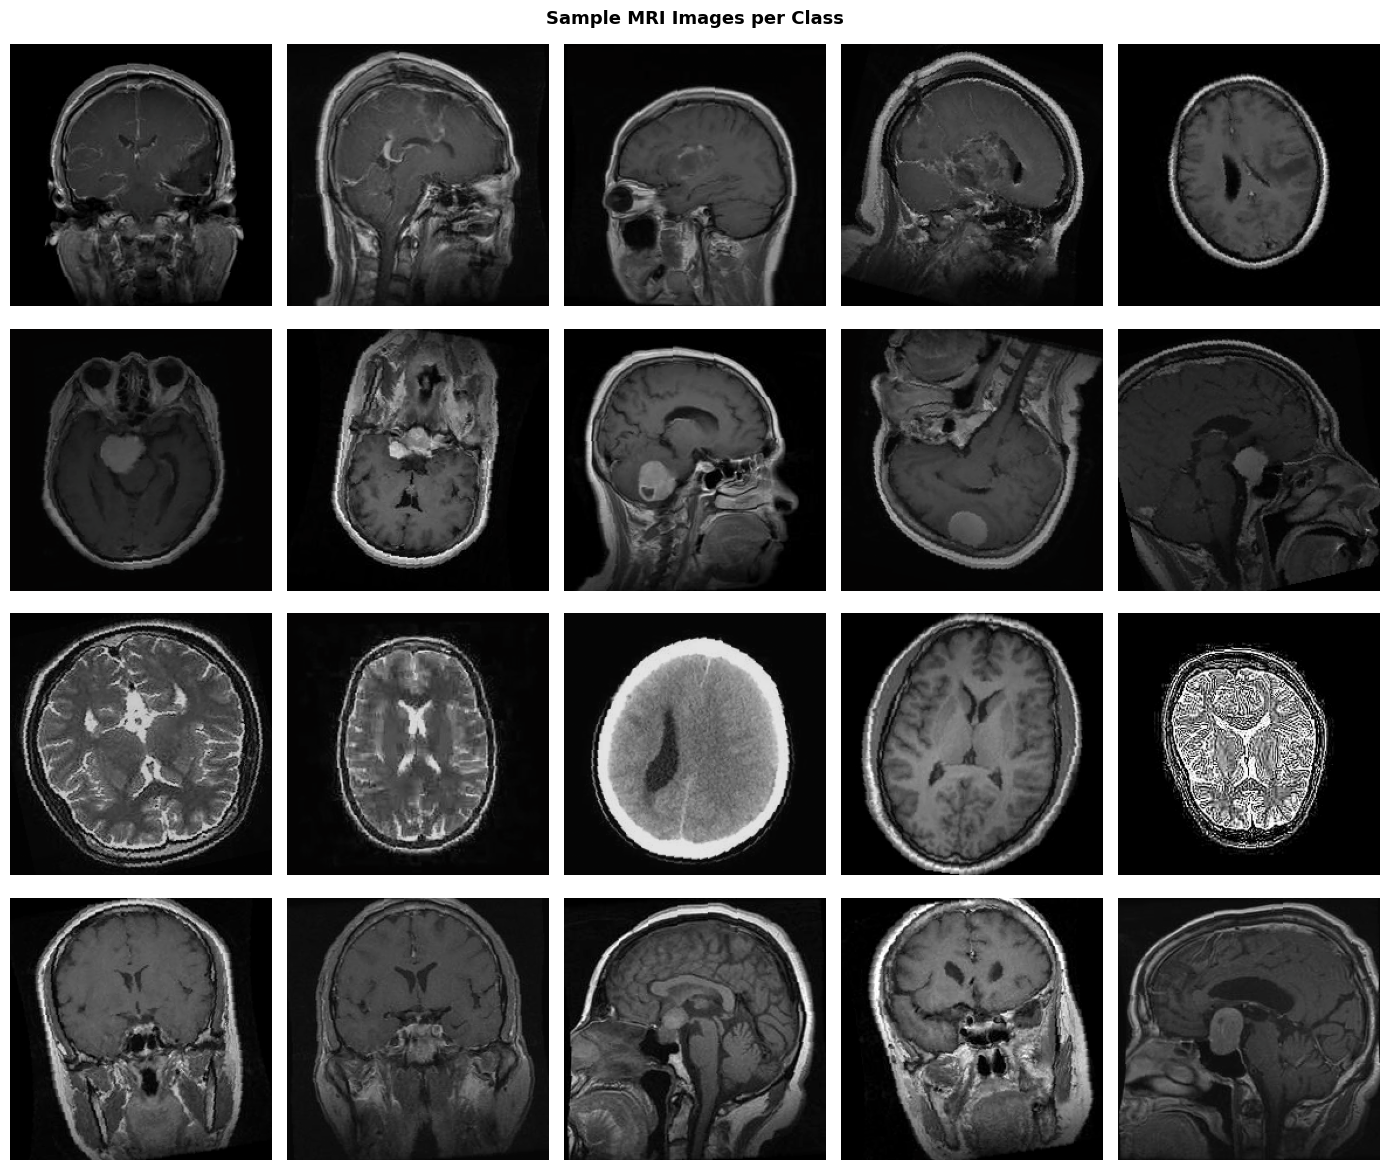

In [6]:
# Show sample MRI images from each class
def denormalise(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 12))
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

shown = {c: 0 for c in range(NUM_CLASSES)}
for img, lbl in train_dataset:
    lbl = lbl
    col = shown[lbl]
    if col < 5:
        img_disp = denormalise(img).permute(1, 2, 0).numpy()
        axes[lbl][col].imshow(img_disp)
        axes[lbl][col].axis('off')
        if col == 0:
            axes[lbl][col].set_ylabel(idx_to_class[lbl], fontsize=10, fontweight='bold')
        shown[lbl] += 1
    if all(v >= 5 for v in shown.values()):
        break

plt.suptitle('Sample MRI Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5 — ViT Model (`transformer.py`)

Using `torchvision.models.vit_b_16` — the standard PyTorch ViT-B/16 (pretrained on ImageNet).  
This is the same architecture as the original repo: 16×16 patches, 12 Transformer blocks, 12 heads.

**Architecture:**
```
Input 3×224×224
  ↓  Patch Embedding  (16×16 patches → 196 tokens, embed_dim=768)
  ↓  [CLS] token + Positional Encoding
  ↓  12 × Transformer Encoder Block
       (LayerNorm → MHSA(12 heads) → LayerNorm → MLP)
  ↓  [CLS] token → Linear(768→4) → Softmax
```

In [7]:
# ── transformer.py ────────────────────────────────────────────────────────
# Load ViT-B/16 pretrained on ImageNet-1k
# (torchvision >= 0.13 — already available on Colab)
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
model = models.vit_b_16(weights=vit_weights)

# Replace the classification head for 4 classes
# Original head: Linear(768, 1000)  →  New: Linear(768, 4)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ViT-B/16 loaded')
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Classification head : Linear({in_features} → {NUM_CLASSES})')
print(f'Classes             : {CLASS_NAMES}')

# Quick shape check
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = model(dummy)
    print(f'\nOutput shape        : {out.shape}  (batch=2, classes={NUM_CLASSES}) ✅')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 176MB/s]


ViT-B/16 loaded
Total parameters    : 85,801,732
Trainable parameters: 85,801,732
Classification head : Linear(768 → 4)
Classes             : ['glioma', 'meningioma', 'notumor', 'pituitary']

Output shape        : torch.Size([2, 4])  (batch=2, classes=4) ✅


## Section 6 — Training (`train.py`)

**Two-phase strategy** (same approach as the original repo):
- **Phase 1** — Freeze backbone, train only the new head (faster, avoids destroying pretrained features)
- **Phase 2** — Unfreeze all layers and fine-tune end-to-end with a lower learning rate

**Optimizer:** AdamW with weight decay  
**Scheduler:** CosineAnnealingLR  
**Loss:** CrossEntropyLoss

In [8]:
# ── train.py — helper functions ───────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += images.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))


print('Training functions defined.')

Training functions defined.


In [9]:
# ── Phase 1: Freeze backbone — train head only ────────────────────────────
P1_EPOCHS = 10
P1_LR     = 1e-3

# Freeze everything except the classification head
for name, param in model.named_parameters():
    param.requires_grad = name.startswith('heads')

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — trainable params: {trainable_p1:,} (head only)')

criterion   = nn.CrossEntropyLoss()
optimizer   = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=P1_LR, weight_decay=1e-4
)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=P1_EPOCHS, eta_min=1e-6
)

history_p1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc_p1 = 0.0

print(f'\nPhase 1 Training ({P1_EPOCHS} epochs) — frozen backbone\n' + '='*60)
for epoch in range(1, P1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = validate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history_p1['train_loss'].append(tr_loss)
    history_p1['train_acc'].append(tr_acc)
    history_p1['val_loss'].append(vl_loss)
    history_p1['val_acc'].append(vl_acc)

    if vl_acc > best_acc_p1:
        best_acc_p1 = vl_acc
        torch.save(model.state_dict(), 'vit_phase1_best.pth')

    print(f'  [{epoch:>2}/{P1_EPOCHS}] '
          f'Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc*100:.2f}%  '
          f'({time.time()-t0:.1f}s)')

print(f'\nBest Phase 1 Val Acc: {best_acc_p1*100:.2f}%')

Phase 1 — trainable params: 3,076 (head only)

Phase 1 Training (10 epochs) — frozen backbone
  [ 1/10] Loss: 0.5340  Acc: 80.62%  |  Val Loss: 0.4932  Val Acc: 81.81%  (84.6s)
  [ 2/10] Loss: 0.3246  Acc: 88.57%  |  Val Loss: 0.4396  Val Acc: 84.56%  (93.0s)
  [ 3/10] Loss: 0.2767  Acc: 90.39%  |  Val Loss: 0.4123  Val Acc: 85.81%  (92.8s)
  [ 4/10] Loss: 0.2508  Acc: 91.07%  |  Val Loss: 0.3951  Val Acc: 87.06%  (92.8s)
  [ 5/10] Loss: 0.2270  Acc: 91.98%  |  Val Loss: 0.4068  Val Acc: 86.75%  (92.4s)
  [ 6/10] Loss: 0.2154  Acc: 92.80%  |  Val Loss: 0.3968  Val Acc: 87.25%  (93.0s)
  [ 7/10] Loss: 0.2066  Acc: 92.98%  |  Val Loss: 0.4064  Val Acc: 86.94%  (92.5s)
  [ 8/10] Loss: 0.2010  Acc: 92.80%  |  Val Loss: 0.3910  Val Acc: 87.38%  (92.8s)
  [ 9/10] Loss: 0.2025  Acc: 92.88%  |  Val Loss: 0.3903  Val Acc: 87.25%  (91.8s)
  [10/10] Loss: 0.1987  Acc: 92.84%  |  Val Loss: 0.3928  Val Acc: 87.31%  (92.1s)

Best Phase 1 Val Acc: 87.38%


In [12]:
# ── Phase 2: Unfreeze all — fine-tune end-to-end ──────────────────────────
P2_EPOCHS = 5
P2_LR     = 1e-5   # much lower LR to avoid destroying pretrained features

# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — trainable params: {trainable_p2:,} (full model)')

optimizer_p2 = optim.AdamW(model.parameters(), lr=P2_LR, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=P2_EPOCHS, eta_min=1e-7
)

history_p2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc_p2 = 0.0

print(f'\nPhase 2 Training ({P2_EPOCHS} epochs) — full fine-tune\n' + '='*60)
for epoch in range(1, P2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_p2, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = validate(model, test_loader, criterion, DEVICE)
    scheduler_p2.step()

    history_p2['train_loss'].append(tr_loss)
    history_p2['train_acc'].append(tr_acc)
    history_p2['val_loss'].append(vl_loss)
    history_p2['val_acc'].append(vl_acc)

    if vl_acc > best_acc_p2:
        best_acc_p2 = vl_acc
        torch.save(model.state_dict(), 'vit_best.pth')

    print(f'  [{epoch:>2}/{P2_EPOCHS}] '
          f'Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc*100:.2f}%  '
          f'({time.time()-t0:.1f}s)')

print(f'\nBest Phase 2 Val Acc: {best_acc_p2*100:.2f}%')

Phase 2 — trainable params: 85,801,732 (full model)

Phase 2 Training (5 epochs) — full fine-tune
  [ 1/5] Loss: 0.0903  Acc: 96.89%  |  Val Loss: 0.3967  Val Acc: 92.75%  (213.1s)
  [ 2/5] Loss: 0.0395  Acc: 98.71%  |  Val Loss: 0.3864  Val Acc: 94.19%  (213.0s)
  [ 3/5] Loss: 0.0235  Acc: 99.20%  |  Val Loss: 0.3328  Val Acc: 95.06%  (213.1s)
  [ 4/5] Loss: 0.0159  Acc: 99.61%  |  Val Loss: 0.3077  Val Acc: 95.69%  (213.5s)
  [ 5/5] Loss: 0.0089  Acc: 99.77%  |  Val Loss: 0.3374  Val Acc: 95.31%  (212.2s)

Best Phase 2 Val Acc: 95.69%


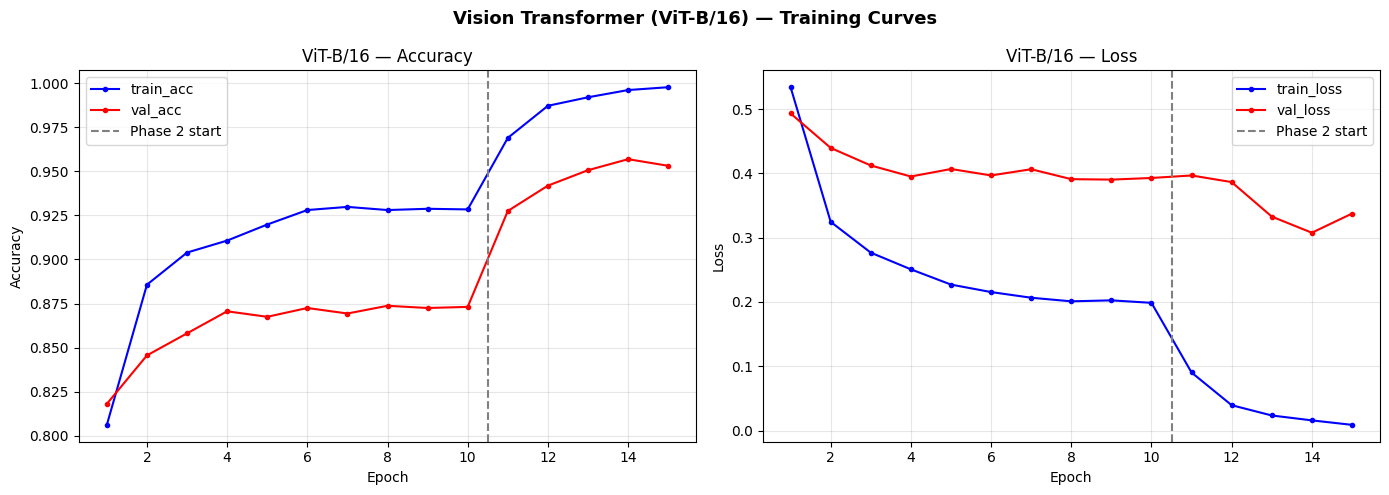

In [13]:
# ── Plot combined training curves ─────────────────────────────────────────
all_train_acc  = history_p1['train_acc']  + history_p2['train_acc']
all_val_acc    = history_p1['val_acc']    + history_p2['val_acc']
all_train_loss = history_p1['train_loss'] + history_p2['train_loss']
all_val_loss   = history_p1['val_loss']   + history_p2['val_loss']
epochs_all     = range(1, len(all_train_acc) + 1)
split          = len(history_p1['train_acc'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_all, all_train_acc,  'b-o', markersize=3, label='train_acc')
ax1.plot(epochs_all, all_val_acc,    'r-o', markersize=3, label='val_acc')
ax1.axvline(split + 0.5, color='gray', ls='--', label='Phase 2 start')
ax1.set_title('ViT-B/16 — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_all, all_train_loss, 'b-o', markersize=3, label='train_loss')
ax2.plot(epochs_all, all_val_loss,   'r-o', markersize=3, label='val_loss')
ax2.axvline(split + 0.5, color='gray', ls='--', label='Phase 2 start')
ax2.set_title('ViT-B/16 — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Vision Transformer (ViT-B/16) — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vit_training_curves.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Testing & Inference (`test.py`)

Load the best saved checkpoint and evaluate on the held-out test set.

**Input:** Test set images (never seen during training)  
**Output:** Classification report (Precision, Recall, F1 per class) + Confusion Matrix

In [14]:
# ── test.py — load best checkpoint and evaluate ───────────────────────────
print('Loading best model checkpoint (vit_best.pth)...')
model.load_state_dict(torch.load('vit_best.pth', map_location=DEVICE))
model.eval()

test_loss, test_acc, y_pred, y_true = validate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '='*60)
print('  TEST RESULTS')
print('='*60)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print('\n  Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Loading best model checkpoint (vit_best.pth)...

  TEST RESULTS
  Test Loss     : 0.3077
  Test Accuracy : 95.69%

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.85      0.92       400
  meningioma       0.92      0.98      0.95       400
     notumor       0.95      1.00      0.97       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



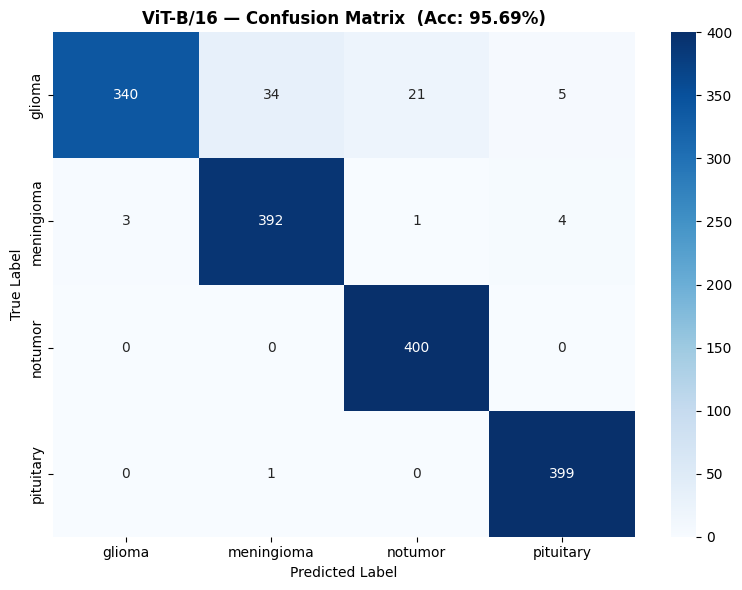

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_title(f'ViT-B/16 — Confusion Matrix  (Acc: {test_acc*100:.2f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('vit_confusion_matrix.jpg', dpi=150, bbox_inches='tight')
plt.show()

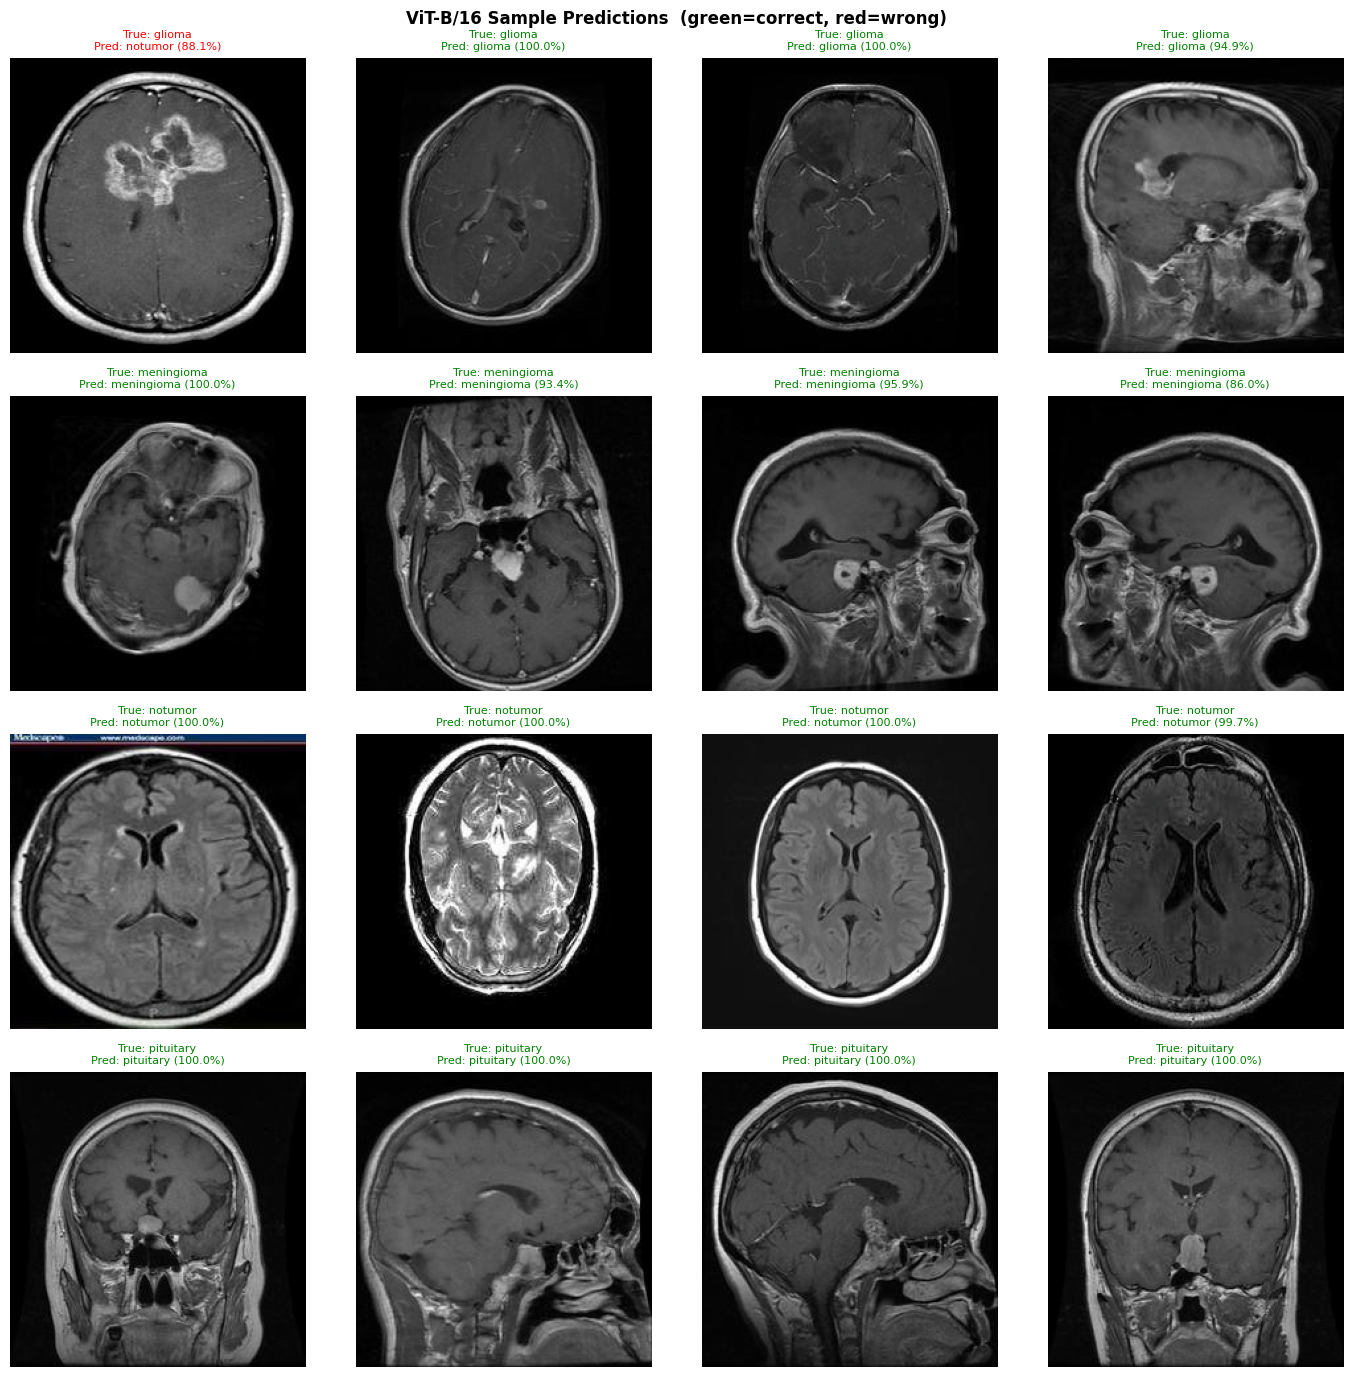

In [16]:
# ── Visual predictions on sample test images ──────────────────────────────
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, 14))

shown  = {c: 0 for c in range(NUM_CLASSES)}
model.eval()

with torch.no_grad():
    for img_tensor, true_lbl in test_dataset:
        col = shown[true_lbl]
        if col >= 4:
            if all(v >= 4 for v in shown.values()):
                break
            continue

        inp  = img_tensor.unsqueeze(0).to(DEVICE)
        out  = model(inp)
        prob = torch.softmax(out, dim=1)
        pred = prob.argmax(1).item()
        conf = prob[0, pred].item() * 100

        img_disp = denormalise(img_tensor).permute(1, 2, 0).numpy()
        ax = axes[true_lbl][col]
        ax.imshow(img_disp)
        ax.axis('off')
        color = 'green' if pred == true_lbl else 'red'
        ax.set_title(
            f'True: {idx_to_class[true_lbl]}\nPred: {idx_to_class[pred]} ({conf:.1f}%)',
            color=color, fontsize=8
        )
        shown[true_lbl] += 1

plt.suptitle('ViT-B/16 Sample Predictions  (green=correct, red=wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8 — Save Model & Metrics

In [17]:
# Save full model
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'class_to_idx': train_dataset.class_to_idx,
    'num_classes': NUM_CLASSES
}, 'vit_brain_tumor_final.pth')
print('Model saved: vit_brain_tumor_final.pth')

# Save metrics as JSON (for comparison notebook)
metrics = {
    'model': 'ViT-B/16',
    'framework': 'PyTorch (torchvision)',
    'pretrained': 'ImageNet-1k',
    'test_accuracy':    float(accuracy_score(y_true, y_pred)),
    'precision_macro':  float(precision_score(y_true, y_pred, average='macro')),
    'recall_macro':     float(recall_score(y_true, y_pred, average='macro')),
    'f1_macro':         float(f1_score(y_true, y_pred, average='macro')),
    'test_loss':        float(test_loss),
    'architecture': {
        'model': 'ViT-B/16',
        'patch_size': 16,
        'embed_dim': 768,
        'depth': 12,
        'num_heads': 12,
        'num_patches': 196
    },
    'training': {
        'phase1_epochs': P1_EPOCHS,
        'phase1_lr': P1_LR,
        'phase2_epochs': P2_EPOCHS,
        'phase2_lr': P2_LR,
        'optimizer': 'AdamW',
        'scheduler': 'CosineAnnealingLR',
        'batch_size': BATCH_SIZE
    }
}

with open('vit_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Metrics saved: vit_metrics.json')
print(json.dumps(metrics, indent=2))

Model saved: vit_brain_tumor_final.pth
Metrics saved: vit_metrics.json
{
  "model": "ViT-B/16",
  "framework": "PyTorch (torchvision)",
  "pretrained": "ImageNet-1k",
  "test_accuracy": 0.956875,
  "precision_macro": 0.9587737265622255,
  "recall_macro": 0.956875,
  "f1_macro": 0.9560183056490246,
  "test_loss": 0.30768702728673814,
  "architecture": {
    "model": "ViT-B/16",
    "patch_size": 16,
    "embed_dim": 768,
    "depth": 12,
    "num_heads": 12,
    "num_patches": 196
  },
  "training": {
    "phase1_epochs": 10,
    "phase1_lr": 0.001,
    "phase2_epochs": 5,
    "phase2_lr": 1e-05,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "batch_size": 32
  }
}
